# Human Capital Migration Analysis

### Project Done by - Sanskar Shrivas
### Date of completion - xx/05/2026

## Data location :- https://www.kaggle.com/datasets/daviddave7100/immigrations-and-emigrations-statistics

## Step 1 - Library and data import and initialization

In [4]:
#1.1 - Fetching important libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
#1.2 - Getting the dataset from the files
path=r'data/data.csv'
df=pd.read_csv(path)
df.head()

,Country,Population,Emigrants Population,Immigrant Population,Net Population Change,Net Population Change to Total Population Ratio,Outbound mobility ratio,Emmigrant to Population Ratio,Immigrants to Population Ratio,GDP per capita
0,Andorra,77700,11132,45574,34442,44.33%,247.65%,14.33%,58.65%,"37,207.22"
1,Luxembourg,627704,81757,298062,216305,34.46%,170.77%,13.02%,47.48%,53489.332
2,San Marino,"34,007",2407,5543,3136,9.22%,129.37%,7.08%,16.30%,"45,321.49"
3,Liechtenstein,39584,3706,25877,22171,56.01%,127.32%,9.36%,65.37%,"165,287.19"
4,Turkmenistan,6046292,242554,194920,-47634,-0.79%,95.54%,4.01%,3.22%,16580.84


## Step 1.6 - Data Cleaning: Convert relevant columns to numeric types

In [6]:
#1.3 - Fetching number of rows and columns in the dataset
df.shape

(201, 10)

In [7]:
#1.4 - Checking for null values
df.isnull().sum()

Country                                            0
Population                                         0
Emigrants Population                               0
Immigrant Population                               0
Net Population Change                              0
Net Population Change to Total Population Ratio    0
Outbound mobility ratio                            0
Emmigrant to Population Ratio                      0
Immigrants to Population Ratio                     0
GDP per capita                                     0
dtype: int64

In [8]:
#1.5 - Checking for true-duplicates
df.duplicated().sum()

np.int64(0)

## Step 2 - Exploratory Data Analytics

In [9]:
#2.1 - Statistical insights for the data
df.describe()

,Emigrants Population,Immigrant Population,Net Population Change
count,2.010000e+02,2.010000e+02,2.010000e+02
mean,1.324783e+06,1.376849e+06,5.206545e+04
std,2.226064e+06,4.177112e+06,4.264051e+06
min,1.740000e+02,2.390000e+02,-1.299079e+07
25%,1.329650e+05,4.954900e+04,-7.817090e+05
50%,6.401600e+05,2.522280e+05,-6.196600e+04
75%,1.489823e+06,1.067090e+06,1.177670e+05
max,1.786949e+07,5.063284e+07,4.763661e+07


In [10]:
#2.2 - Which countries have the highest and lowest net population change?
print("Maximum :")
res=df[['Country','Net Population Change']].sort_values(by='Net Population Change',ascending=False).iloc[0]
print(res)

print("Minimum :")
res=df[['Country','Net Population Change']].sort_values(by='Net Population Change',ascending=True).iloc[0]
print(res)

Maximum :
Country                  United States
Net Population Change         47636613
Name: 111, dtype: object
Minimum :
Country                      India
Net Population Change    -12990788
Name: 99, dtype: object


In [11]:
# Convert GDP per capita and Net Population Change to float
df['GDP per capita']=df['GDP per capita'].astype(str).str.replace(',', '').astype(float)
df['Net Population Change']=df['Net Population Change'].astype(str).str.replace(',', '').astype(float)

0.27099217683594523


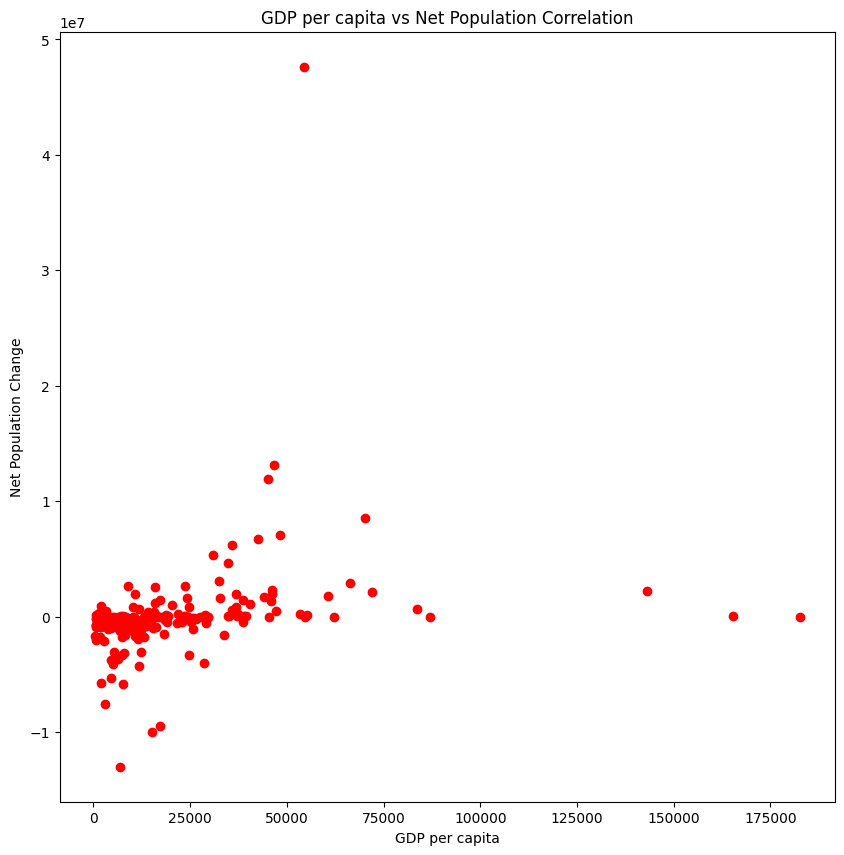

In [12]:
#2.3 - GPD Per capita vs Net Population Correlation
res = df['GDP per capita'].corr(df['Net Population Change'])
print(res)

x=df['GDP per capita']
y=df['Net Population Change']
plt.figure(figsize=(10,10))
plt.scatter(x,y,color='red')
plt.xlabel('GDP per capita')
plt.ylabel('Net Population Change')
plt.title('GDP per capita vs Net Population Correlation')
plt.show()

In [13]:
#2.4 - Identify countries with the highest and lowest values for Outbound mobility ratio, Emmigrant to Population Ratio, and Immigrants to Population Ratio.
res=df.sort_values(by='Outbound mobility ratio',ascending=False).iloc[0]['Country']+" - "+df.sort_values(by='Outbound mobility ratio',ascending=False).iloc[0]['Outbound mobility ratio']
print("Highest Outbound mobility ratio :\n"+res)
print('---------------------------------')
res=df.sort_values(by='Outbound mobility ratio',ascending=True).iloc[0]['Country']+" - "+df.sort_values(by='Outbound mobility ratio',ascending=True).iloc[0]['Outbound mobility ratio']
print("Lowest Outbound mobility ratio :\n"+res)
print('=================================')
res=df.sort_values(by='Emmigrant to Population Ratio',ascending=False).iloc[0]['Country']+" - "+df.sort_values(by='Emmigrant to Population Ratio',ascending=False).iloc[0]['Emmigrant to Population Ratio']
print("Highest Emigration to population ratio :\n"+res)
print('---------------------------------')
res=df.sort_values(by='Emmigrant to Population Ratio',ascending=True).iloc[0]['Country']+" - "+df.sort_values(by='Emmigrant to Population Ratio',ascending=True).iloc[0]['Emmigrant to Population Ratio']
print("Lowest Emigration to population ratio :\n"+res)
print('=================================')
res=df.sort_values(by='Immigrants to Population Ratio',ascending=False).iloc[0]['Country']+" - "+df.sort_values(by='Immigrants to Population Ratio',ascending=False).iloc[0]['Immigrants to Population Ratio']
print("Highest Emigration to population ratio :\n"+res)
print('---------------------------------')
res=df.sort_values(by='Immigrants to Population Ratio',ascending=True).iloc[0]['Country']+" - "+df.sort_values(by='Immigrants to Population Ratio',ascending=True).iloc[0]['Immigrants to Population Ratio']
print("Lowest Emigration to population ratio :\n"+res)

Highest Outbound mobility ratio :
Turkmenistan - 95.54%
---------------------------------
Lowest Outbound mobility ratio :
Dominica - 0.00%
Highest Emigration to population ratio :
Honduras - 9.92%
---------------------------------
Lowest Emigration to population ratio :
Papua New Guinea - 0.05%
Highest Emigration to population ratio :
Portugal - 9.83%
---------------------------------
Lowest Emigration to population ratio :
Cuba - 0.03%


In [14]:
# Convert percentage columns to float
df['Outbound mobility ratio']=df['Outbound mobility ratio'].astype(str).str.replace('%', '').astype(float)
df['Immigrants to Population Ratio']=df['Immigrants to Population Ratio'].astype(str).str.replace('%', '').astype(float)
df['Emmigrant to Population Ratio']=df['Emmigrant to Population Ratio'].astype(str).str.replace('%', '').astype(float)
df['Population']=df['Population'].astype(str).str.replace(',', '').astype(float)

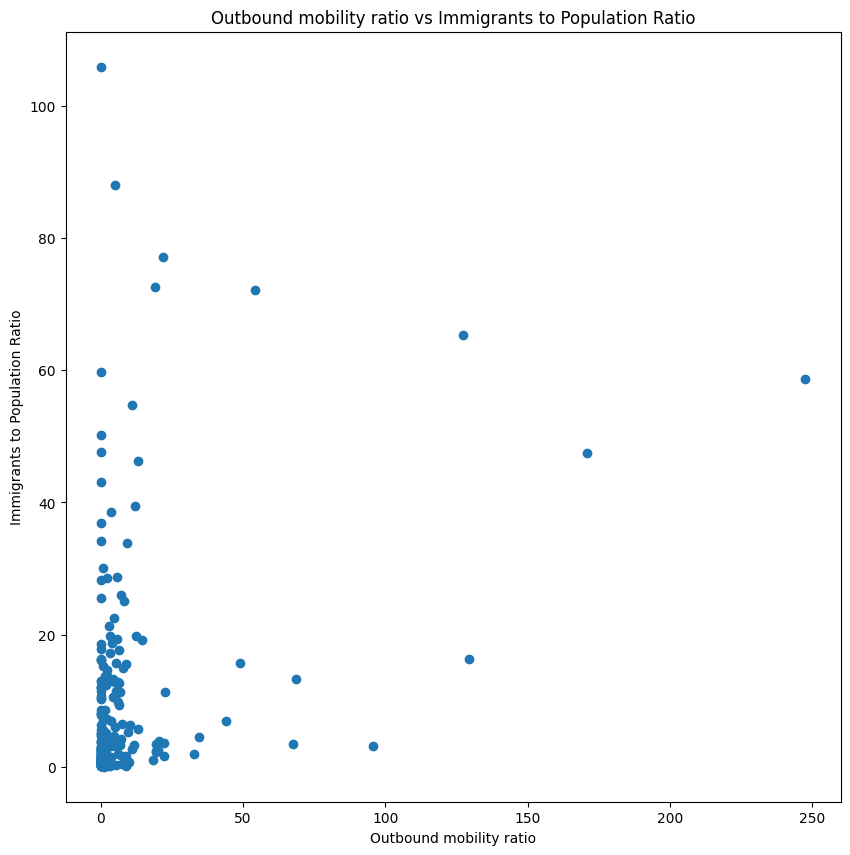

In [15]:
#2.5 - How are the Outbound mobility ratio and Immigrants to Population Ratio distributed across all countries? Are there any clusters or outliers?
x=df['Outbound mobility ratio']
y=df['Immigrants to Population Ratio']
plt.figure(figsize=(10,10))
plt.scatter(x,y)
plt.xlabel('Outbound mobility ratio')
plt.ylabel('Immigrants to Population Ratio')
plt.title('Outbound mobility ratio vs Immigrants to Population Ratio')
plt.show()

# Step 3 - VIsuaization

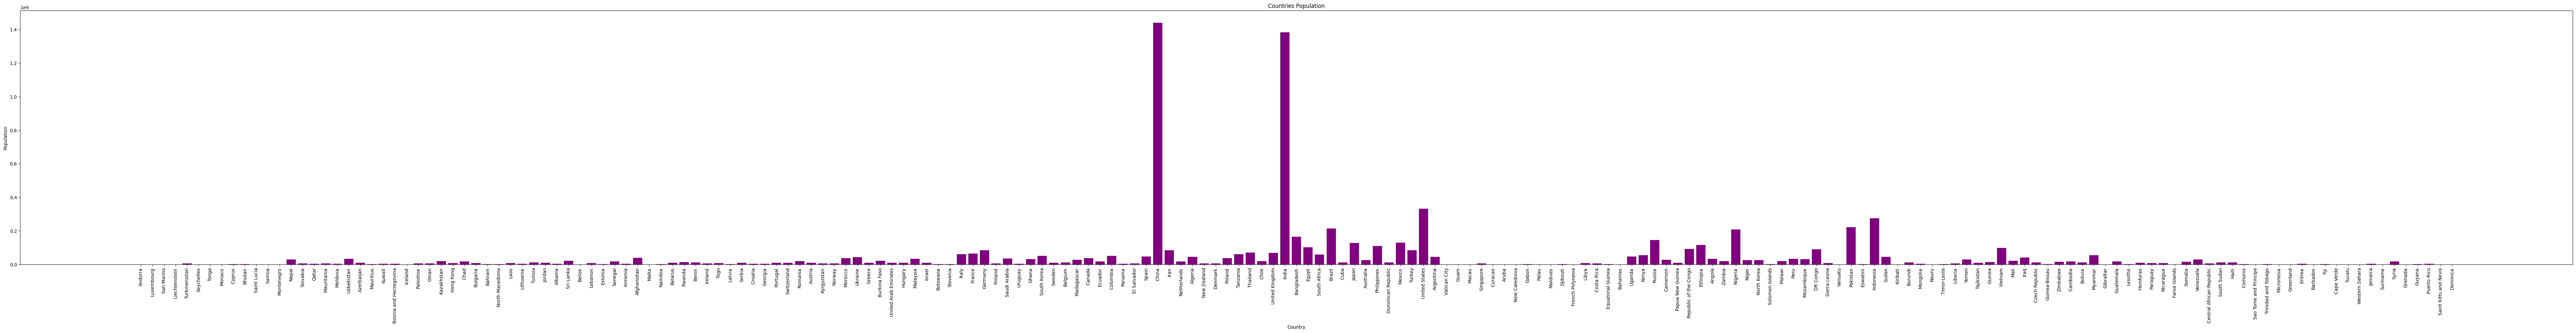

In [16]:
#3.1 - countries population
x=df['Country']
y=df['Population']
plt.figure(figsize=(100,10))
plt.bar(x,y,color='purple')
plt.xlabel('Country')
plt.ylabel('Population')
plt.title('Countries Population')
plt.xticks(rotation=90)
plt.show()

Text(0.5, 1.0, 'Immigration vs Emmigration')

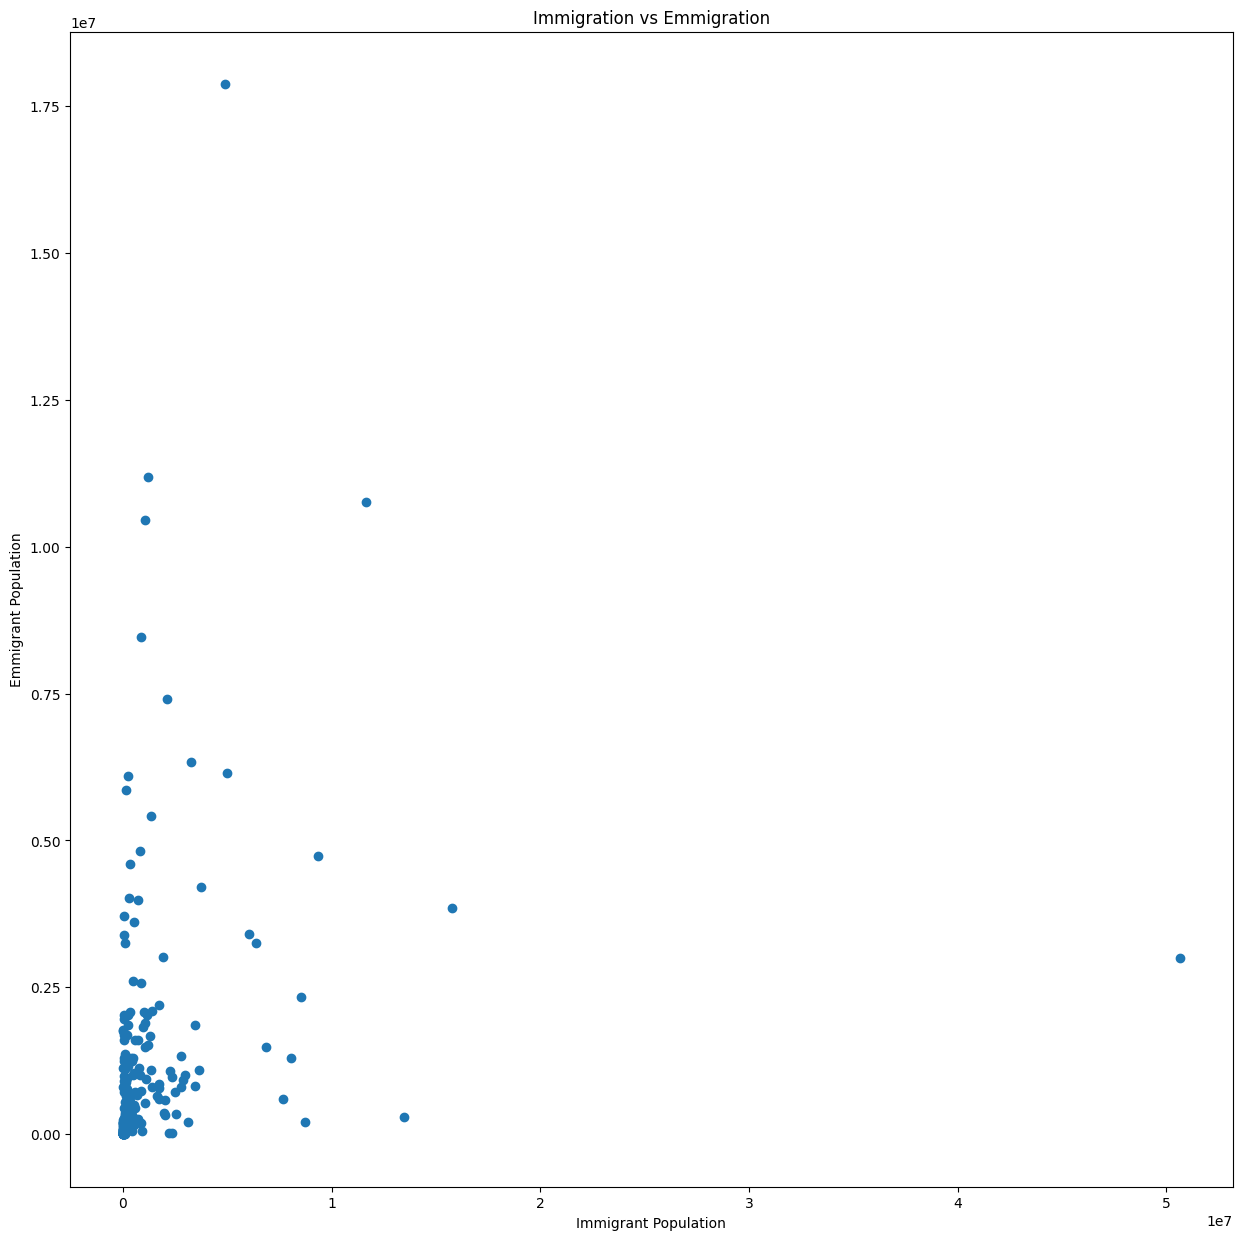

In [17]:
#3.2 - Immigration vs Emmigration chart
x=df['Immigrant Population']
y=df['Emigrants Population']
plt.figure(figsize=(15,15))
plt.scatter(x,y)
plt.xlabel('Immigrant Population')
plt.ylabel('Emmigrant Population')
plt.title('Immigration vs Emmigration')

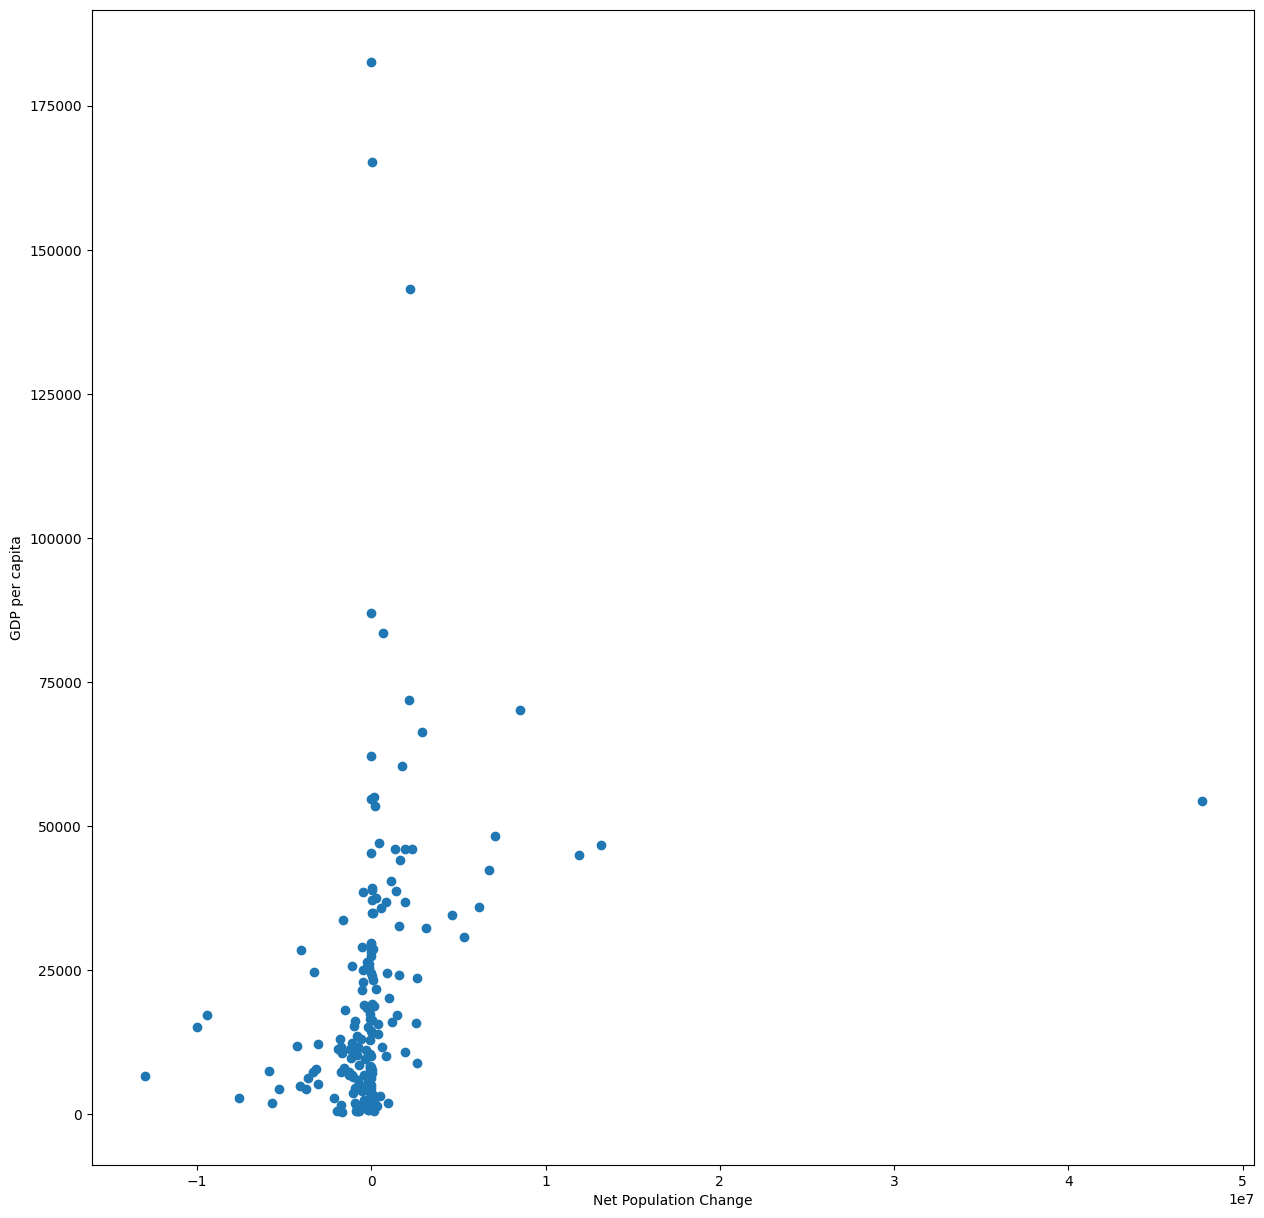

In [18]:
#3.3 - Net population change vs GDP
x=df['Net Population Change']
y=df['GDP per capita']
plt.figure(figsize=(15,15))
plt.scatter(x,y)
plt.xlabel('Net Population Change')
plt.ylabel('GDP per capita')
plt.show()

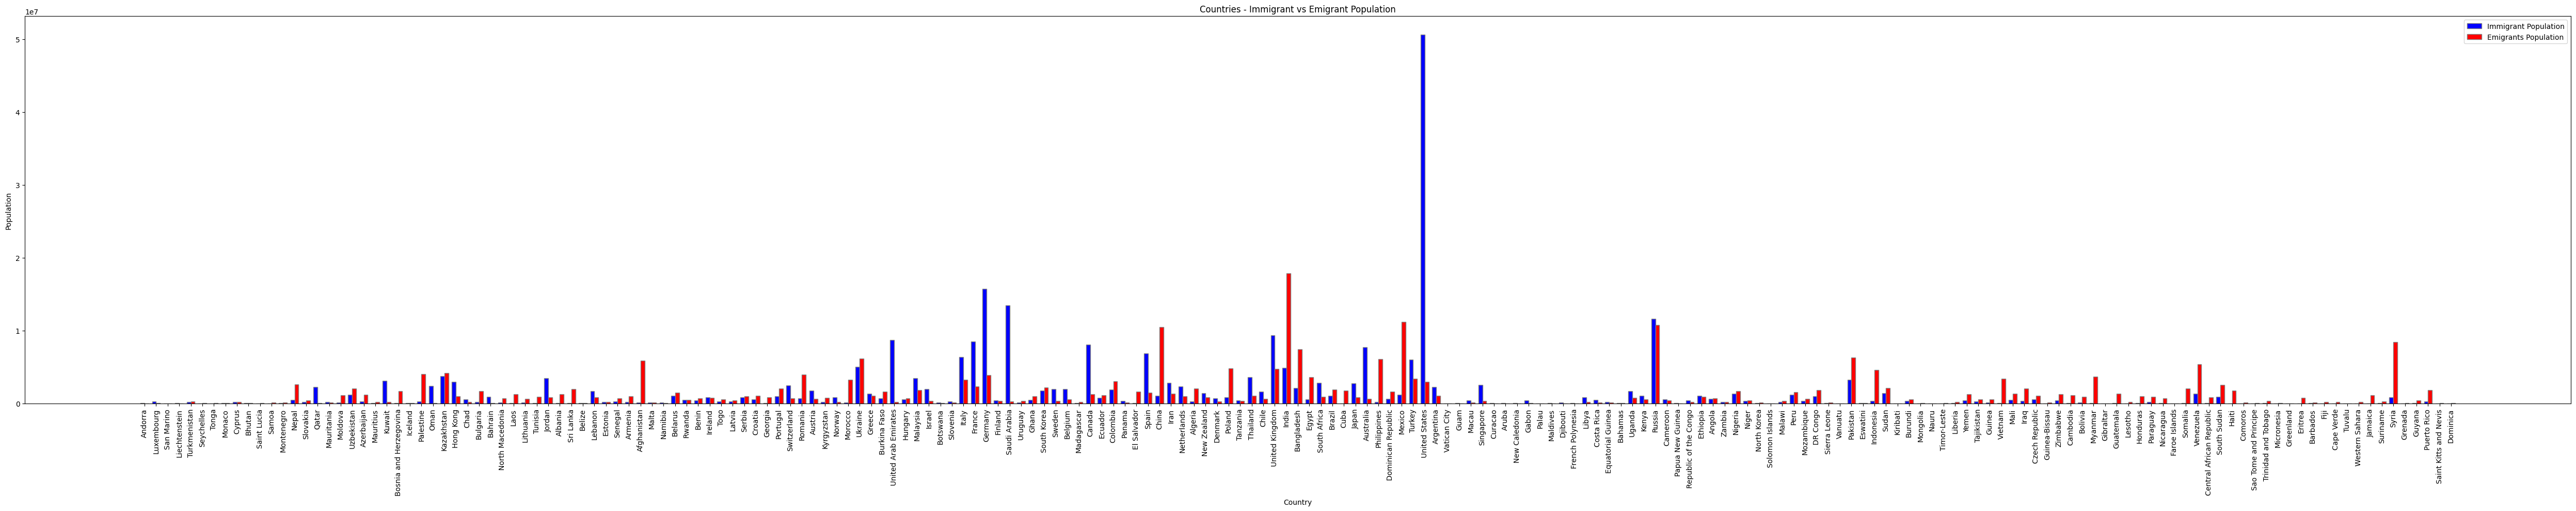

In [19]:
#3.4 - country wise emigration and immigration bar plot
x = df['Country']
y = df['Immigrant Population']
z = df['Emigrants Population']

bar_width = 0.35
r1 = np.arange(len(x))
r2 = [x_val + bar_width for x_val in r1]

plt.figure(figsize=(50, 10))
plt.bar(r1, y, color='blue', width=bar_width, edgecolor='grey', label='Immigrant Population')
plt.bar(r2, z, color='red', width=bar_width, edgecolor='grey', label='Emigrants Population')

plt.xlabel('Country')
plt.ylabel('Population')
plt.title('Countries - Immigrant vs Emigrant Population')
plt.xticks([r + bar_width / 2 for r in range(len(x))], x, rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

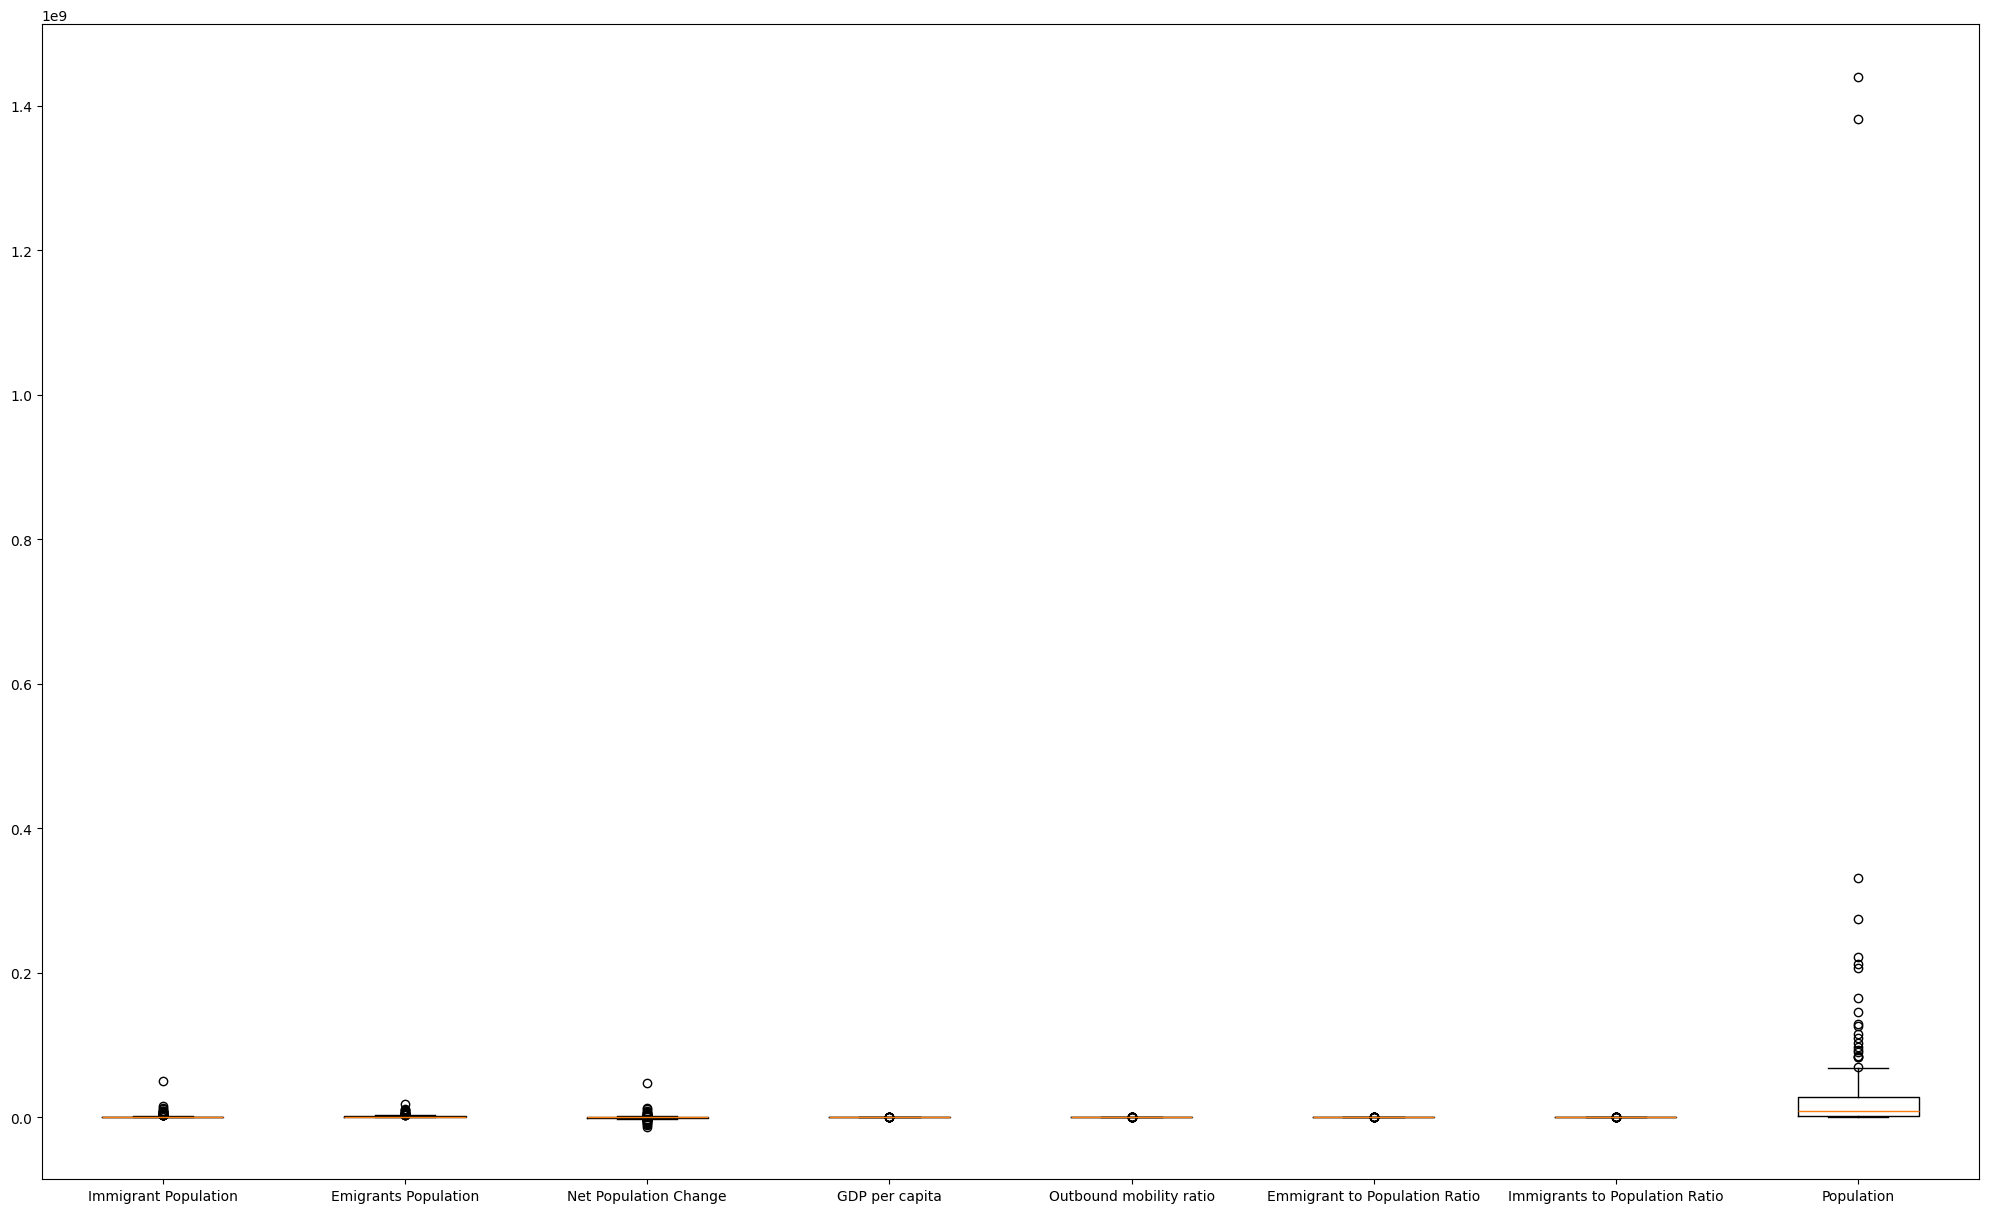

In [20]:
#boxplot for each field
x=df['Immigrant Population']
y=df['Emigrants Population']
z=df['Net Population Change']
w=df['GDP per capita']
a=df['Outbound mobility ratio']
b=df['Emmigrant to Population Ratio']
c=df['Immigrants to Population Ratio']
d=df['Population']
plt.figure(figsize=(25,15))
plt.boxplot([x,y,z,w,a,b,c,d])
plt.xticks([1,2,3,4,5,6,7,8],['Immigrant Population','Emigrants Population','Net Population Change','GDP per capita','Outbound mobility ratio','Emmigrant to Population Ratio','Immigrants to Population Ratio','Population'])
plt.show()